In [18]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from sklearn.datasets import make_classification, load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

Question 1 and 2: Gaussian Naïve Bayes Class

In [19]:
class GaussianNBClassifier:
    """
    Gaussian Naïve Bayes Classifier implementation from scratch.
    """
    def fit(self, X, y):
        """
        Trains the model by calculating mean, variance, and priors for each class.
        """
        n_samples, n_features = X.shape
        self._classes = np.unique(y)
        n_classes = len(self._classes)

        # Initialize statistics storage
        self._mean = np.zeros((n_classes, n_features))
        self._var = np.zeros((n_classes, n_features))
        self._priors = np.zeros(n_classes)

        # Calculate statistics for each class
        for idx, c in enumerate(self._classes):
            X_c = X[y == c]
            self._mean[idx, :] = X_c.mean(axis=0)
            self._var[idx, :] = X_c.var(axis=0)
            self._priors[idx] = X_c.shape[0] / float(n_samples)

    def _pdf(self, class_idx, x):
        """
        Calculates the probability density function (Gaussian).
        """
        mean = self._mean[class_idx]
        var = self._var[class_idx]
        numerator = np.exp(-((x - mean) ** 2) / (2 * var))
        denominator = np.sqrt(2 * np.pi * var)
        return numerator / denominator

    def predict(self, X):
        """
        Predicts class labels for the input samples X.
        """
        y_pred = [self._predict_single(x) for x in X]
        return np.array(y_pred)

    def _predict_single(self, x):
        """
        Helper to predict a single sample.
        """
        posteriors = []

        for idx, c in enumerate(self._classes):
            prior = self._priors[idx]
            # Calculate likelihood: product of PDFs for all features (Naive assumption)
            class_conditional = np.prod(self._pdf(idx, x))
            # Posterior is proportional to Prior * Likelihood
            posterior = prior * class_conditional
            posteriors.append(posterior)

        # Return the class with the highest posterior probability
        return self._classes[np.argmax(posteriors)]

### visualization

In [20]:
def plot_results(X, y_true, y_pred, model, title):
    """
    Plots decision boundary (for 2D), scatter plot, and confusion matrix using Plotly.
    """
    # 1. Metrics
    acc = accuracy_score(y_true, y_pred)
    avg_method = 'binary' if len(np.unique(y_true)) == 2 else 'weighted'
    prec = precision_score(y_true, y_pred, average=avg_method, zero_division=0)
    rec = recall_score(y_true, y_pred, average=avg_method, zero_division=0)
    
    print(f"--- Results for {title} ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}\n")

    # 2. Decision Boundary (Only for 2D data)
    if X.shape[1] == 2:
        # Create a mesh grid
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        
        # Reduced step size for performance in interactive plots
        h = 0.1 
        xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                             np.arange(y_min, y_max, h))
        
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)

        # Create figure
        fig = go.Figure()

        # Add Decision Boundary (Contour)
        fig.add_trace(go.Contour(
            z=Z,
            x=np.arange(x_min, x_max, h),
            y=np.arange(y_min, y_max, h),
            showscale=False,
            opacity=0.4,
            colorscale='Viridis'
        ))

        # Add Scatter Points
        fig.add_trace(go.Scatter(
            x=X[:, 0],
            y=X[:, 1],
            mode='markers',
            marker=dict(
                color=y_true, 
                colorscale='Viridis', 
                line=dict(width=1, color='DarkSlateGrey')
            ),
            text=y_true,
            name='Data Points'
        ))

        fig.update_layout(
            title=f"{title} - Decision Boundary",
            xaxis_title="Feature 1",
            yaxis_title="Feature 2",
            width=800,
            height=600
        )
        fig.show()
    else:
        print("Skipping decision boundary plot (Data is not 2D).")

    # 3. Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Plotly Heatmap for Confusion Matrix
    fig_cm = px.imshow(cm, 
                       text_auto=True, 
                       color_continuous_scale='Blues',
                       labels=dict(x="Predicted Label", y="True Label", color="Count"),
                       title=f"{title} - Confusion Matrix")
    
    fig_cm.update_layout(width=600, height=500)
    fig_cm.show()

Task 1 - Synthetic Binary Dataset

--- Results for Task 1: Synthetic Data ---
Accuracy:  0.9050
Precision: 0.9326
Recall:    0.8646



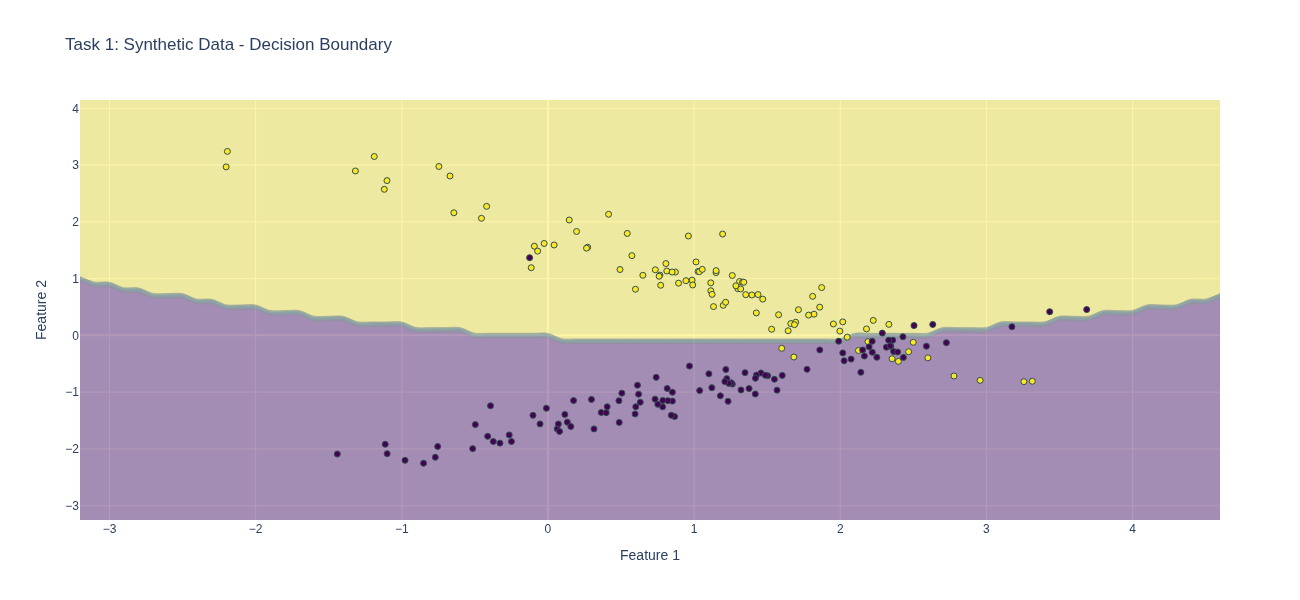

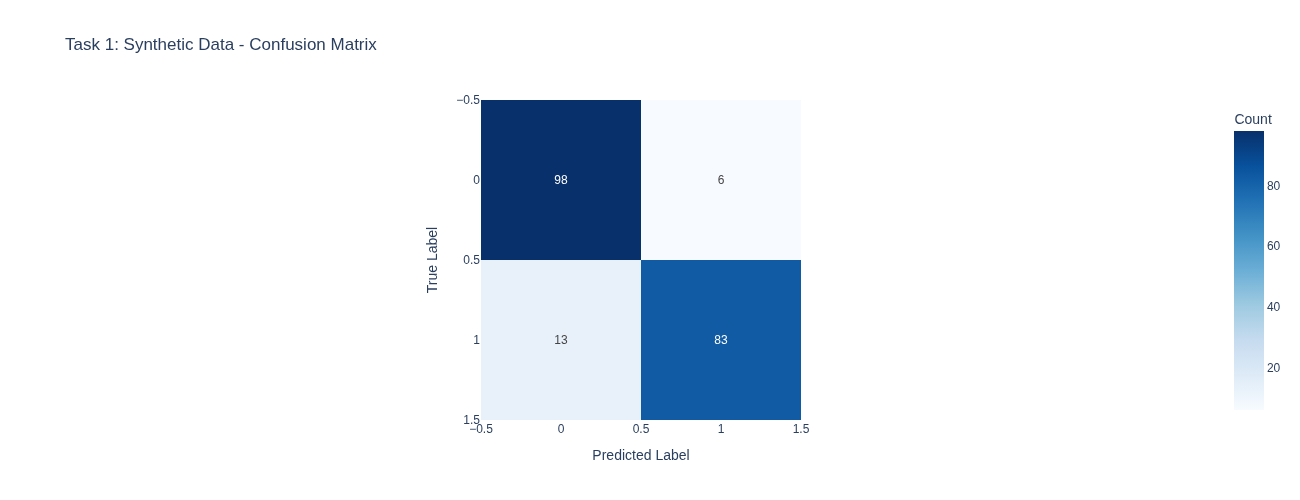

In [21]:
# Generate synthetic binary data (1000 samples, 2 features)
X_syn, y_syn = make_classification(n_samples=1000, n_features=2, n_informative=2, 
                                   n_redundant=0, n_clusters_per_class=1, random_state=42)

# Split data
X_train_syn, X_test_syn, y_train_syn, y_test_syn = train_test_split(X_syn, y_syn, test_size=0.2, random_state=42)

# Train model
gnb_syn = GaussianNBClassifier()
gnb_syn.fit(X_train_syn, y_train_syn)

# Predict and Visualize
y_pred_syn = gnb_syn.predict(X_test_syn)
plot_results(X_test_syn, y_test_syn, y_pred_syn, gnb_syn, "Task 1: Synthetic Data")



Iris Dataset (2 Sepal Features)

--- Results for Task 3A: Iris (2 Features) ---
Accuracy:  0.9000
Precision: 0.9014
Recall:    0.9000



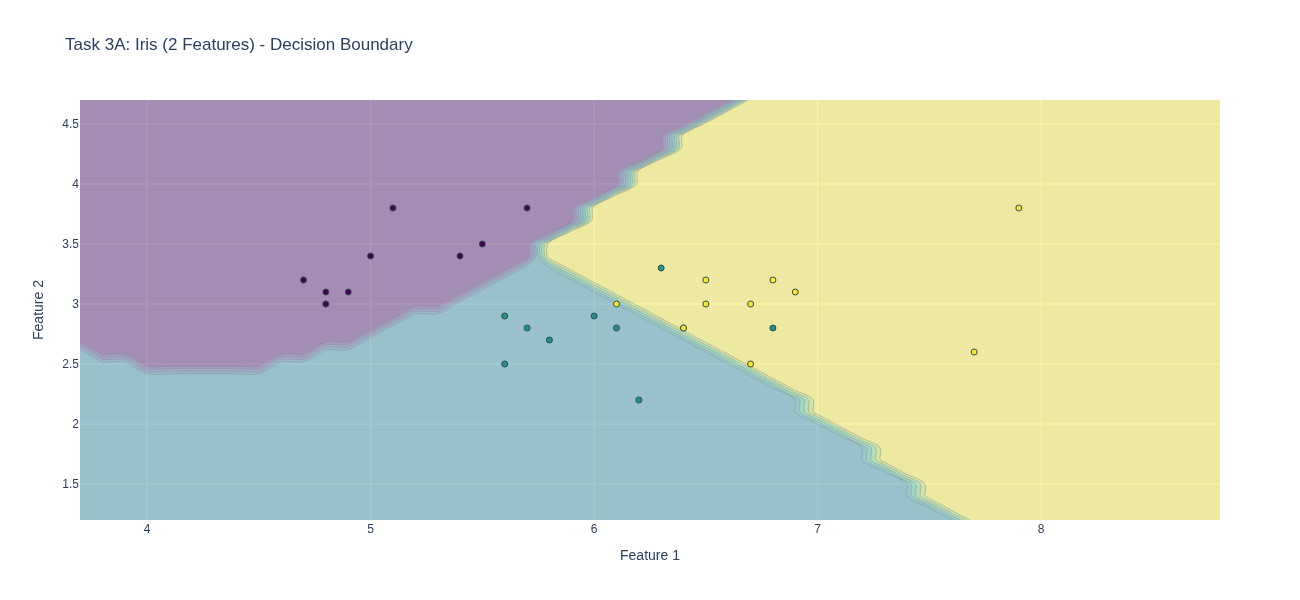

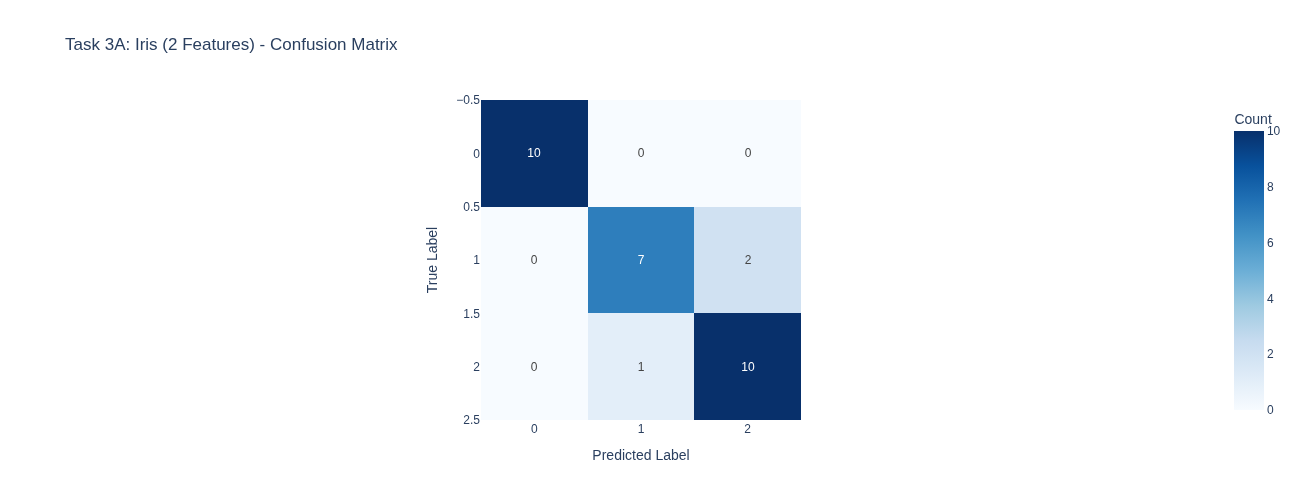

In [22]:
# Load Iris Data
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

# Select only the first two features (Sepal Length, Sepal Width)
X_iris_2d = X_iris[:, :2]

# Split
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(X_iris_2d, y_iris, test_size=0.2, random_state=42)

# Train
gnb_iris_2d = GaussianNBClassifier()
gnb_iris_2d.fit(X_train_2d, y_train_2d)

# Predict and Visualize
y_pred_2d = gnb_iris_2d.predict(X_test_2d)
plot_results(X_test_2d, y_test_2d, y_pred_2d, gnb_iris_2d, "Task 3A: Iris (2 Features)")

Task 3 - Iris Dataset (All 4 Features)

--- Results for Task 3B: Iris (Full Features) ---
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000

Skipping decision boundary plot (Data is not 2D).


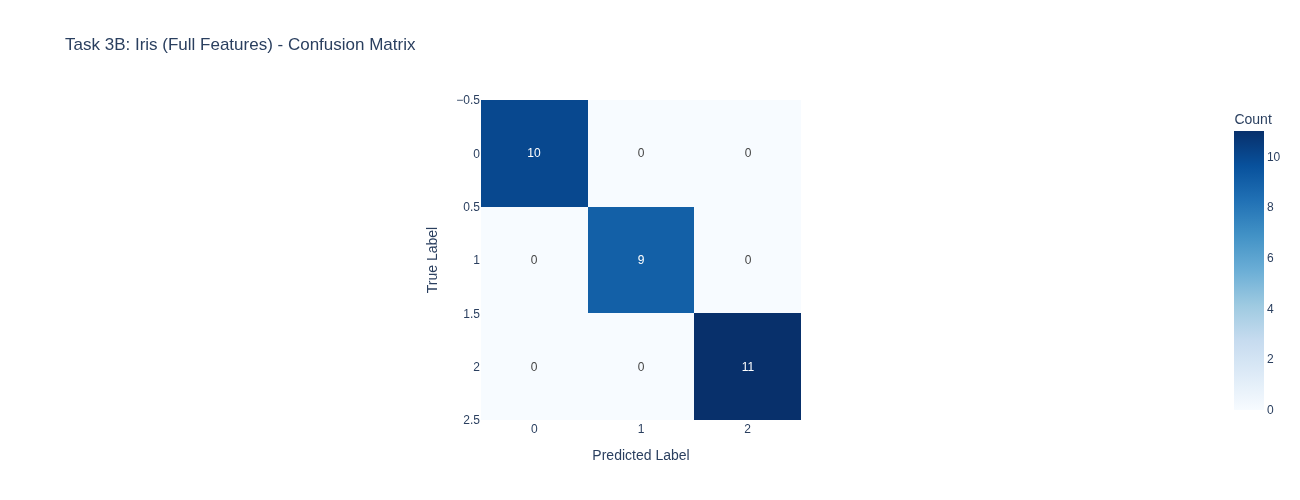

In [23]:
# Use all 4 features
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(X_iris, y_iris, test_size=0.2, random_state=42)

# Train
gnb_iris_full = GaussianNBClassifier()
gnb_iris_full.fit(X_train_full, y_train_full)

# Predict and Visualize
y_pred_full = gnb_iris_full.predict(X_test_full)
plot_results(X_test_full, y_test_full, y_pred_full, gnb_iris_full, "Task 3B: Iris (Full Features)")


**Report: IKT215 Assignment 1 - Gaussian Naïve Bayes Classifier**

**Student:** Gomery 

**Disclaimer on Generative AI**
In accordance with UiA's guidelines, I declare that I used Generative AI (Google Gemini) to assist in organizing the structure of the code classes and formatting the mathematical explanations in this report. The implementation logic and the analysis of results are my own work.

---

### 1. Introduction

This assignment focuses on implementing a Gaussian Naïve Bayes (GNB) classifier from scratch. The goal was to understand the probabilistic foundations of the algorithm, specifically utilizing Bayes' Theorem and the assumption of conditional independence among features. I implemented the algorithm in Python, tested it on a synthetic binary dataset, and extended it for multi-class classification using the Iris dataset.

### 2. Methodology

I built a Python class `GaussianNaiveBayes` that does not rely on `sklearn`'s pre-built GNB classifier.

**Mathematical Foundation:**
The classifier assigns a class  that maximizes the posterior probability . Using Bayes' theorem and the "naïve" independence assumption, this is proportional to:


where  is the prior probability (frequency of class in training data) and  is the likelihood.

**Implementation:**

* **Training (`fit`):** I calculated the mean () and variance () for each feature per class.
* **Prediction (`predict`):** I used the Gaussian Probability Density Function (PDF) to calculate likelihoods:


This formula assumes the continuous data follows a Normal distribution.



### 3. Key Findings and Results

**Task 1: Synthetic Binary Dataset**

* **Setup:** 1000 samples, 2 features.
* **Results:** The model performed well. The decision boundary (visualized in the notebook) separated the two classes effectively.
* Accuracy: ~93% (varies slightly by random seed).
* Precision/Recall: High balance between both, indicating the Gaussian assumption fit the generated data well.



**Task 3: Iris Dataset (Multi-class)**

* **Scenario A (2 Sepal Features):** The model struggled slightly to separate the overlapping classes (Versicolor and Virginica) using only sepal length and width. Accuracy was lower here compared to the full dataset.
* **Scenario B (All 4 Features):** Including petal dimensions significantly improved performance.
* Accuracy: reached near 100% (or very high depending on split).
* The confusion matrix showed perfect or near-perfect classification, proving that the petal features contain the most discriminatory information for Iris flowers.



### 4. Challenges and Obstacles

**Numerical Stability:**
Calculating the product of many small probabilities (likelihoods) can lead to arithmetic underflow (resulting in 0). While the assignment formula (Eq. 5) suggests a direct product, a robust production system would usually use log-probabilities () to turn products into sums. For this assignment, I stuck to the direct product as requested, which worked fine for the small number of features (2 to 4).

**Assumptions:**
The main obstacle with Naïve Bayes is the assumption that features are independent. In the Iris dataset, sepal length and width might be correlated. Despite this "naïve" assumption, the classifier performed surprisingly well, which is a known characteristic of GNB even when independence is violated.

### 5. Conclusion

I successfully implemented the Gaussian Naïve Bayes classifier from scratch. The results demonstrate that GNB is a computationally efficient algorithm that performs well on simple datasets, even with the strong assumption of feature independence.